# Загрузка и первичная подготовка данных

Используемые библиотеки:
- pandas — для работы с таблицами
- numpy — для численных операций
- matplotlib / seaborn — для визуализации
- missingno — специализированная библиотека для анализа пропусков

In [3]:
# Импорт библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

# Настройки отображения
pd.set_option('display.max_columns', None)

# Загрузка данных
df = pd.read_csv("/Users/eyeoftheigor/Documents/GitHub/loan_prediction_dataset.csv")

# Просмотр первых строк
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Общая информация о датасете

Методы:
- info() — показывает:
  - количество строк
  - типы данных
  - наличие пропусков
- describe() — показывает статистики:
  - для числовых - mean, std, min, max
  - для категориальных - уникальные значения, частоты

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


# Анализ пропусков

Ниже считаются:
- абсолютное количество пропусков
- доля пропусков (в %)

In [6]:
missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': df.isna().mean() * 100
})

missing_table = missing_table[missing_table['missing_count'] > 0]
missing_table.sort_values(by='missing_percent', ascending=False)

,missing_count,missing_percent
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


# Визуальный анализ пропусков

Используются:
1. Матрица пропусков (missingno.matrix)
2. Тепловая карта (missingno.heatmap)

## Матрица пропусков

Что показывает:
- каждая строка = объект
- каждый столбец = признак
- белые значения = пропуски

На что обращается особое внимание:
- есть ли вертикальные полосы - системные пропуски
- есть ли горизонтальные разрывы - пропуски по объектам

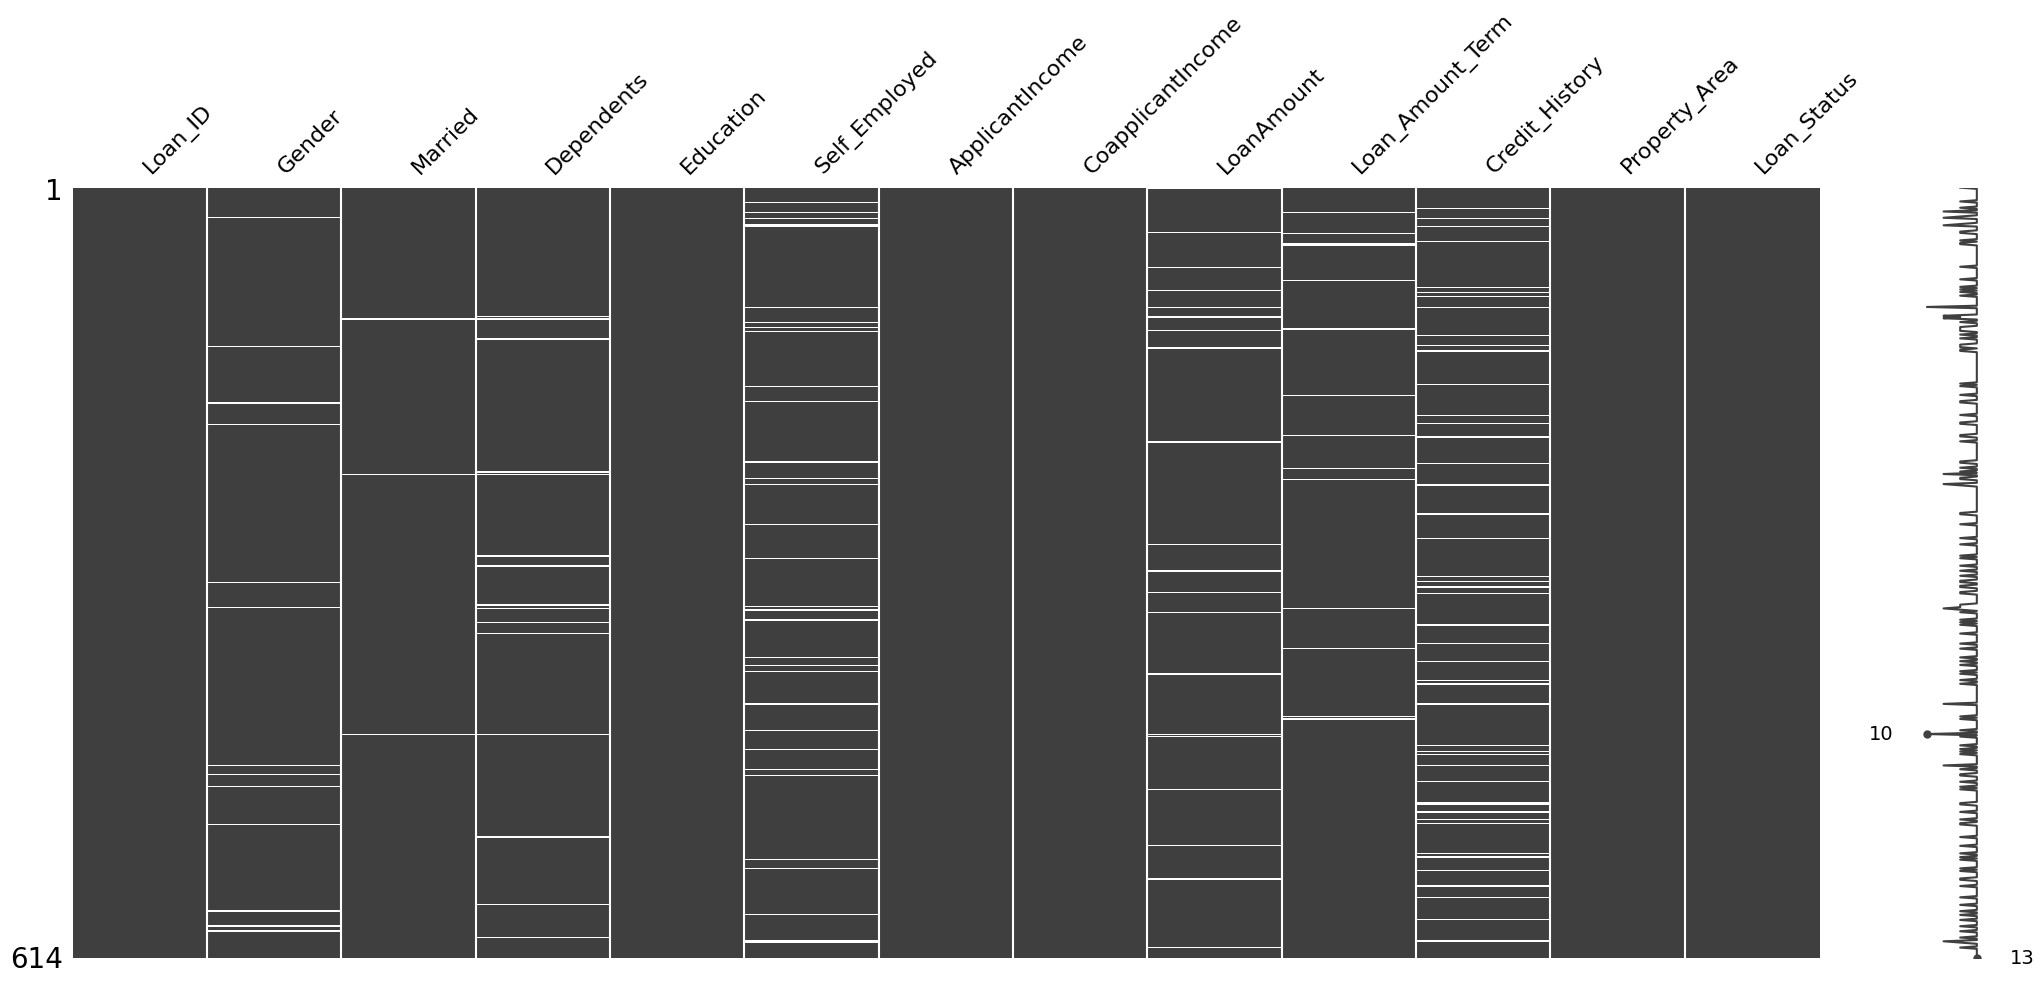

In [7]:
msno.matrix(df)
plt.show()

## Тепловая карта пропусков

Показывает корреляцию пропусков между признаками

Интерпретация:
- значение близко к 1 - пропуски возникают одновременно
- значение близко к 0 - независимы

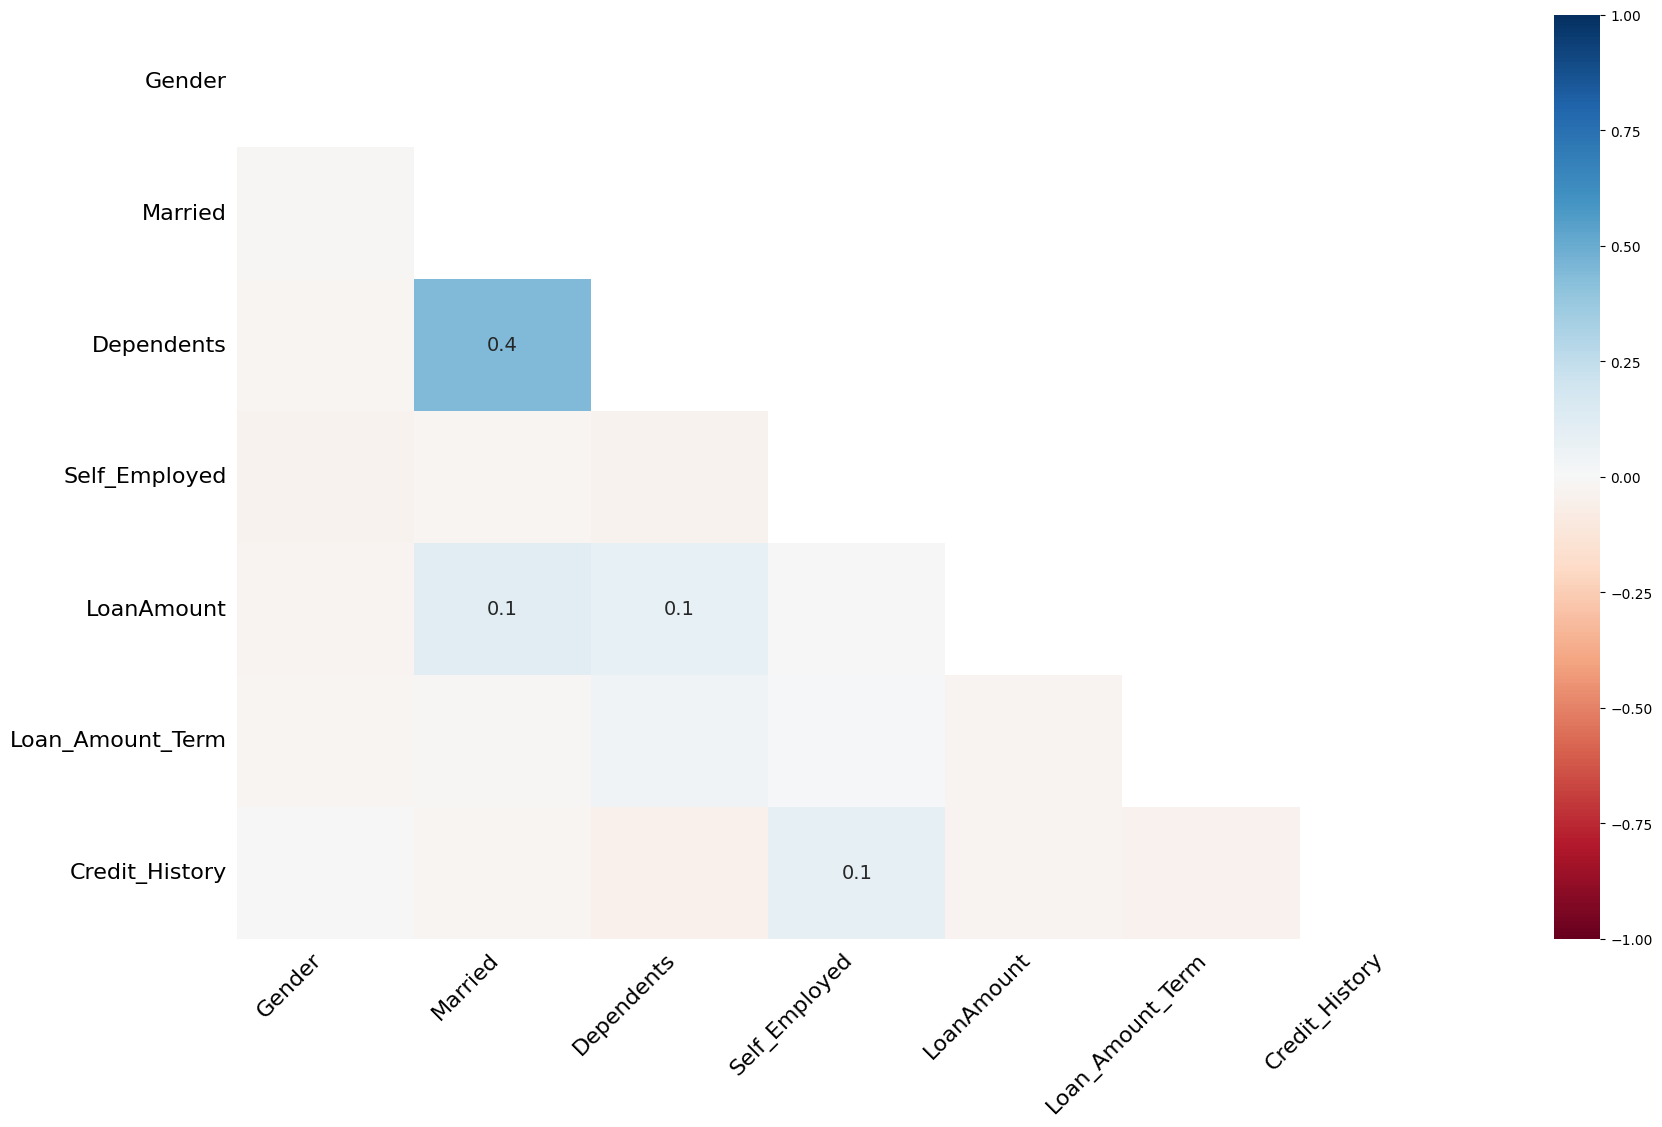

In [8]:
msno.heatmap(df)
plt.show()

# Интерпретация результатов

1. Если пропуски распределены хаотично:
   - можно считать их случайными (MCAR)

2. Если есть зависимости между признаками:
   - пропуски не случайны (MAR)

3. Если целые блоки данных отсутствуют:
   - возможны проблемы сбора данных

# Разделение признаков по типам

Числовые и категориальные признаки требуют разных методов обработки пропусков

- числовые - int, float
- категориальные - object

In [9]:
# Числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Категориальные признаки
cat_cols = df.select_dtypes(include=['object']).columns

# Оставляем только те, где есть пропуски
num_with_nan = [col for col in num_cols if df[col].isna().sum() > 0]
cat_with_nan = [col for col in cat_cols if df[col].isna().sum() > 0]

num_with_nan, cat_with_nan

(['LoanAmount', 'Loan_Amount_Term', 'Credit_History'],
 ['Gender', 'Married', 'Dependents', 'Self_Employed'])

# Заполнение пропусков

#### Числовые признаки
Используется медиана, потому что она устойчива к выбросам и не сильно искажает распределение.

#### Категориальные признаки
Использую mode(), благодаря чему получаю наиболее вероятное значение с сохранением распределения категорий.

Сохраняю исходные данные для последующего сравнения.

In [10]:
df_before = df.copy()

Заполняю пропуски в числовых признаках медианой каждого столбца.

In [16]:
for col in num_with_nan:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

Так же заполняю пропуски в категориальных признаках модой (самым частым значением).

In [22]:
for col in cat_with_nan:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

# Проверка заполнения

Цель:
- убедиться, что пропусков больше нет
- проверить корректность выполнения операций

In [23]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [19]:
# Жесткая проверка
assert df.isna().sum().sum() == 0

# Анализ изменений после заполнения

Цель:
- оценить влияние импутации
- убедиться, что данные критически не искажены

### Числовые признаки

Cравниваю основные статистики:
- среднее
- медиану
- стандартное отклонение

In [20]:
df_before[num_with_nan].describe(), df[num_with_nan].describe()

(       LoanAmount  Loan_Amount_Term  Credit_History
 count  592.000000         600.00000      564.000000
 mean   146.412162         342.00000        0.842199
 std     85.587325          65.12041        0.364878
 min      9.000000          12.00000        0.000000
 25%    100.000000         360.00000        1.000000
 50%    128.000000         360.00000        1.000000
 75%    168.000000         360.00000        1.000000
 max    700.000000         480.00000        1.000000,
        LoanAmount  Loan_Amount_Term  Credit_History
 count  614.000000        614.000000      614.000000
 mean   145.752443        342.410423        0.855049
 std     84.107233         64.428629        0.352339
 min      9.000000         12.000000        0.000000
 25%    100.250000        360.000000        1.000000
 50%    128.000000        360.000000        1.000000
 75%    164.750000        360.000000        1.000000
 max    700.000000        480.000000        1.000000)

### Категориальные признаки

Сравниваю распределения категорий (в долях).

In [21]:
for col in cat_with_nan:
    display(
        pd.DataFrame({
            'before': df_before[col].value_counts(normalize=True),
            'after': df[col].value_counts(normalize=True)
        })
    )

,before,after
Gender,,
Male,0.813644,0.81759
Female,0.186356,0.18241


,before,after
Married,,
Yes,0.651391,0.653094
No,0.348609,0.346906


,before,after
Dependents,,
0,0.575960,0.586319
1,0.170284,0.166124
2,0.168614,0.164495
3+,0.085142,0.083062


,before,after
Self_Employed,,
No,0.859107,0.86645
Yes,0.140893,0.13355


# Итоговые выводы

1. Пропуски были успешно обработаны:
   - отсутствуют NaN значения
   - данные готовы для моделирования

2. Числовые признаки:
   - медиана сохранилась
   - среднее могло незначительно измениться
   - распределение стало более устойчивым

3. Категориальные признаки:
   - увеличилась доля наиболее частого значения (при заполнении модой эффект ожидаемый)

4. Качество подхода:
   - метод простой и интерпретируемый

5. Ограничения:
   - не учитывает зависимости между признаками